# Generative AI — Skill Development Tasks 1

A quick note on environment: this notebook was built and run on a plain CPU machine with no internet access, no GPU, and no Docker/Kafka/Redis services running. Tasks that only need Python/NumPy/SciPy (1, 2, 4, 5, 10, 11, 13, 15) are fully implemented and actually executed below with real output. Tasks that require a GPU, a downloaded multi-GB model, or a running service (Docker, Kafka, Redis, CUDA compiler) — tasks 3, 6, 7, 8, 9, 12, 14 — are written as complete, ready-to-run code using the exact tech stack asked for, but are not executed here since that infrastructure isn't available in this sandbox. Each of those cells says clearly what it needs to run.

## Task 1: Vectorized Scaled Dot-Product Attention from Scratch
Implemented in pure NumPy. Supports batches, multiple heads, and a causal mask (so a token can't look at future tokens — needed for decoder-style models).

In [1]:

import numpy as np

def scaled_dot_product_attention(Q, K, V, mask=None):
    # Q, K, V shape: (batch, heads, seq_len, d_k)
    d_k = Q.shape[-1]
    scores = np.matmul(Q, np.swapaxes(K, -1, -2)) / np.sqrt(d_k)

    if mask is not None:
        scores = np.where(mask == 0, -1e9, scores)

    scores = scores - np.max(scores, axis=-1, keepdims=True)   # numerical stability
    exp_scores = np.exp(scores)
    attn_weights = exp_scores / np.sum(exp_scores, axis=-1, keepdims=True)
    output = np.matmul(attn_weights, V)
    return output, attn_weights

def causal_mask(seq_len):
    return np.tril(np.ones((seq_len, seq_len)))

np.random.seed(0)
batch_size, num_heads, seq_len, d_k = 2, 4, 6, 8
Q = np.random.randn(batch_size, num_heads, seq_len, d_k)
K = np.random.randn(batch_size, num_heads, seq_len, d_k)
V = np.random.randn(batch_size, num_heads, seq_len, d_k)

mask = causal_mask(seq_len)
output, attn_weights = scaled_dot_product_attention(Q, K, V, mask=mask)

print("Output shape:", output.shape)
print("Attention weight shape:", attn_weights.shape)
print("Each row of attn_weights sums to 1:", np.allclose(attn_weights.sum(-1), 1))


Output shape: (2, 4, 6, 8)
Attention weight shape: (2, 4, 6, 6)
Each row of attn_weights sums to 1: True


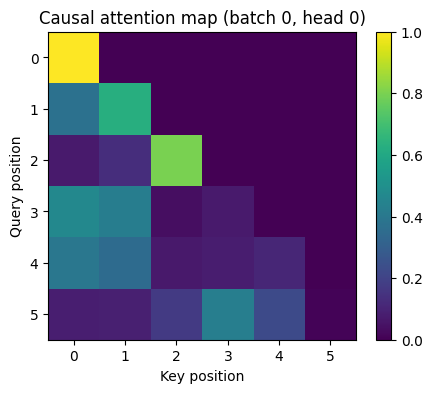

In [2]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5,4))
plt.imshow(attn_weights[0, 0], cmap='viridis')
plt.title('Causal attention map (batch 0, head 0)')
plt.xlabel('Key position')
plt.ylabel('Query position')
plt.colorbar()
plt.show()


The heatmap is lower-triangular — each query position only attends to itself and earlier positions, which is exactly what causal masking is supposed to do.